In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

In [5]:
crop_df  = pd.read_csv("C:/Users/dell/Desktop/crop_production.csv")
crop_df

,State_Name,Crop_Year,Season,Crop,Area,Production
0,Uttar Pradesh,2001,Kharif,Rice,49142.31,102324.71
1,Uttar Pradesh,2001,Kharif,Maize,36757.56,91362.83
2,Uttar Pradesh,2001,Kharif,Soyabean,47596.96,102323.80
3,Uttar Pradesh,2001,Kharif,Cotton,5671.60,17136.34
4,Uttar Pradesh,2001,Kharif,Sugarcane,24716.79,54893.22
...,...,...,...,...,...,...
11610,Telangana,2009,Rabi,Barley,1066.84,2039.36
11611,Bihar,2012,Rabi,Gram,70532.25,70838.08
11612,Madhya Pradesh,2006,Kharif,Jowar,38340.54,78944.09
11613,Assam,2004,Kharif,Bajra,30822.00,60916.88


In [6]:
price_df = pd.read_csv("C:/Users/dell/Desktop/market_prices.csv")

,Month,Rice,Wheat,Maize,Soyabean,Cotton,Groundnut,Sugarcane,Mustard,Gram,Barley
0,2001-01,319.77,231.82,180.74,409.77,539.60,547.44,140.94,460.62,370.87,208.79
1,2001-02,308.71,230.62,189.12,465.35,629.01,538.16,156.43,461.53,422.37,211.47
2,2001-03,285.51,243.72,179.01,NaN,560.82,510.24,165.10,493.29,384.07,205.55
3,2001-04,289.99,238.85,186.92,NaN,555.52,519.32,146.86,473.73,396.49,202.40
4,2001-05,314.62,224.25,201.98,444.85,591.82,523.63,154.74,446.49,385.36,205.88
...,...,...,...,...,...,...,...,...,...,...,...
271,2023-08,442.86,367.45,398.14,523.63,641.28,680.04,236.08,621.90,538.80,319.77
272,2023-09,382.58,321.22,414.50,608.50,718.92,NaN,383.90,567.73,414.66,327.99
273,2023-10,378.04,440.44,385.57,519.32,713.69,589.67,NaN,574.32,440.82,276.24
274,2023-11,487.82,422.55,406.99,546.51,651.03,724.83,326.38,681.00,584.29,401.16


In [7]:
crop_df.columns  = crop_df.columns.str.strip().str.lower()
price_df.columns = price_df.columns.str.strip().str.lower()

if 'yield_per_hectare' not in crop_df.columns:
    crop_df['yield_per_hectare'] = crop_df['production'] / crop_df['area'].replace(0, np.nan)
    print('yield_per_hectare column created from production / area')

crop_df = crop_df.dropna(subset=['production', 'area', 'yield_per_hectare'])
crop_df = crop_df[crop_df['area'] > 0]

print(f'Crop Production — Shape : {crop_df.shape}')
print(f'Market Prices   — Shape : {price_df.shape}')
print(f'\n Crop DF Columns  : {crop_df.columns.tolist()}')
print(f'Price DF Columns : {price_df.columns.tolist()}')
print()
crop_df.head(3)

yield_per_hectare column created from production / area
Crop Production — Shape : (10902, 7)
Market Prices   — Shape : (276, 11)

 Crop DF Columns  : ['state_name', 'crop_year', 'season', 'crop', 'area', 'production', 'yield_per_hectare']
Price DF Columns : ['month', 'rice', 'wheat', 'maize', 'soyabean', 'cotton', 'groundnut', 'sugarcane', 'mustard', 'gram', 'barley']



,state_name,crop_year,season,crop,area,production,yield_per_hectare
0,Uttar Pradesh,2001,Kharif,Rice,49142.31,102324.71,2.08
1,Uttar Pradesh,2001,Kharif,Maize,36757.56,91362.83,2.49
2,Uttar Pradesh,2001,Kharif,Soyabean,47596.96,102323.80,2.15


In [11]:
total_production = crop_df['production'].sum()
total_area       = crop_df['area'].sum()
avg_yield        = crop_df['yield_per_hectare'].mean()
unique_states    = crop_df['state_name'].nunique()
unique_crops     = crop_df['crop'].nunique()
year_range       = f"{int(crop_df['crop_year'].min())} – {int(crop_df['crop_year'].max())}"

print('='*55)
print('NATIONAL AGRICULTURE — KPI SUMMARY')
print('='*55)
print(f'  Total Production    : {total_production:,.0f} tonnes')
print(f'  Total Area Covered  : {total_area:,.0f} hectares')
print(f'  Avg Yield/Hectare   : {avg_yield:.2f} tonnes/ha')
print(f'  States Covered      : {unique_states}')
print(f'  Unique Crops        : {unique_crops}')
print(f'  Year Range          : {year_range}')
print('='*55)

NATIONAL AGRICULTURE — KPI SUMMARY
  Total Production    : 1,176,097,007 tonnes
  Total Area Covered  : 437,979,029 hectares
  Avg Yield/Hectare   : 2.68 tonnes/ha
  States Covered      : 20
  Unique Crops        : 25
  Year Range          : 2001 – 2023


---
## 4. Production Growth Rate — Decade-wise

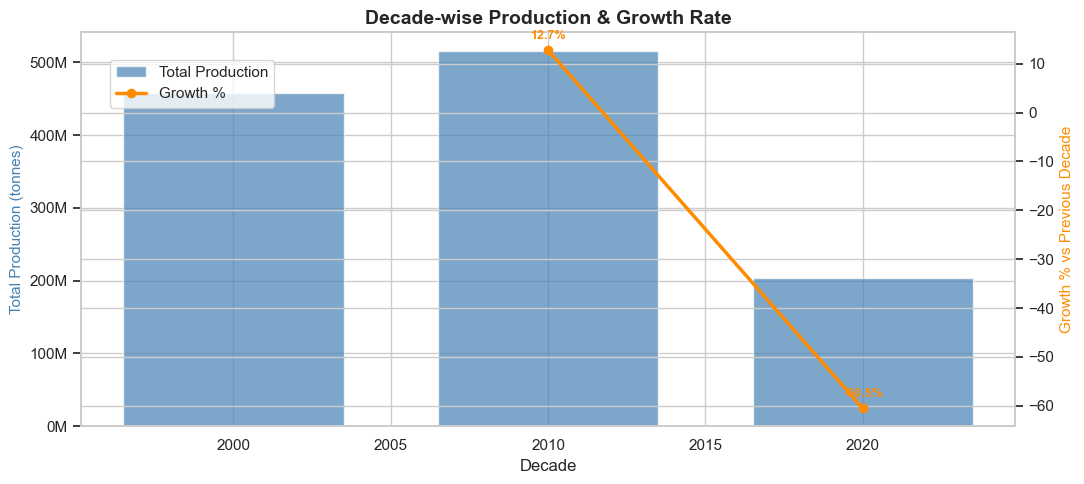


 Decade-wise Production Table
 decade   production  growth_%
   2000 457149750.33       NaN
   2010 515384510.79     12.74
   2020 203562746.05    -60.50


In [26]:
crop_df['decade'] = (crop_df['crop_year'] // 10) * 10
decade_prod = crop_df.groupby('decade')['production'].sum().reset_index()
decade_prod['growth_%'] = decade_prod['production'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(decade_prod['decade'], decade_prod['production'],
        color='steelblue', alpha=0.7, width=7, label='Total Production')
ax2.plot(decade_prod['decade'], decade_prod['growth_%'],
         color='darkorange', marker='o', linewidth=2.5, label='Growth %')
for _, row in decade_prod.dropna(subset=['growth_%']).iterrows():
    ax2.annotate(f"{row['growth_%']:.1f}%",
                 (row['decade'], row['growth_%']),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=9, color='darkorange', fontweight='bold')

ax1.set_xlabel('Decade', fontsize=12)
ax1.set_ylabel('Total Production (tonnes)', color='steelblue', fontsize=11)
ax2.set_ylabel('Growth % vs Previous Decade', color='darkorange', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.title('Decade-wise Production & Growth Rate', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.show()

print('\n Decade-wise Production Table')
print(decade_prod.to_string(index=False))

best_decade = decade_prod.dropna(subset=['growth_%']).loc[decade_prod['growth_%'].idxmax()]

---
## 5. Supply Gap Analysis — High Area, Low Yield States

In [27]:
state_summary = crop_df.groupby('state_name').agg(
    total_area       = ('area',              'sum'),
    total_production = ('production',        'sum'),
    avg_yield        = ('yield_per_hectare', 'mean')
).reset_index()
med_area  = state_summary['total_area'].median()
med_yield = state_summary['avg_yield'].median()

state_summary['supply_gap'] = (
    (state_summary['total_area']  > med_area) &
    (state_summary['avg_yield']   < med_yield)
)

gap_states = state_summary[state_summary['supply_gap']].sort_values('avg_yield')

print(f'States with Supply Gap (High Area, Low Yield): {len(gap_states)}')
print()
print(gap_states[['state_name', 'total_area', 'total_production', 'avg_yield']].to_string(index=False))

States with Supply Gap (High Area, Low Yield): 4

      state_name  total_area  total_production  avg_yield
           Bihar 22571207.78       31111900.28       1.38
         Gujarat 22885118.91       31664124.04       1.38
Himachal Pradesh 22233074.81       39791183.77       1.79
     Uttarakhand 22143587.12       39929159.41       1.80


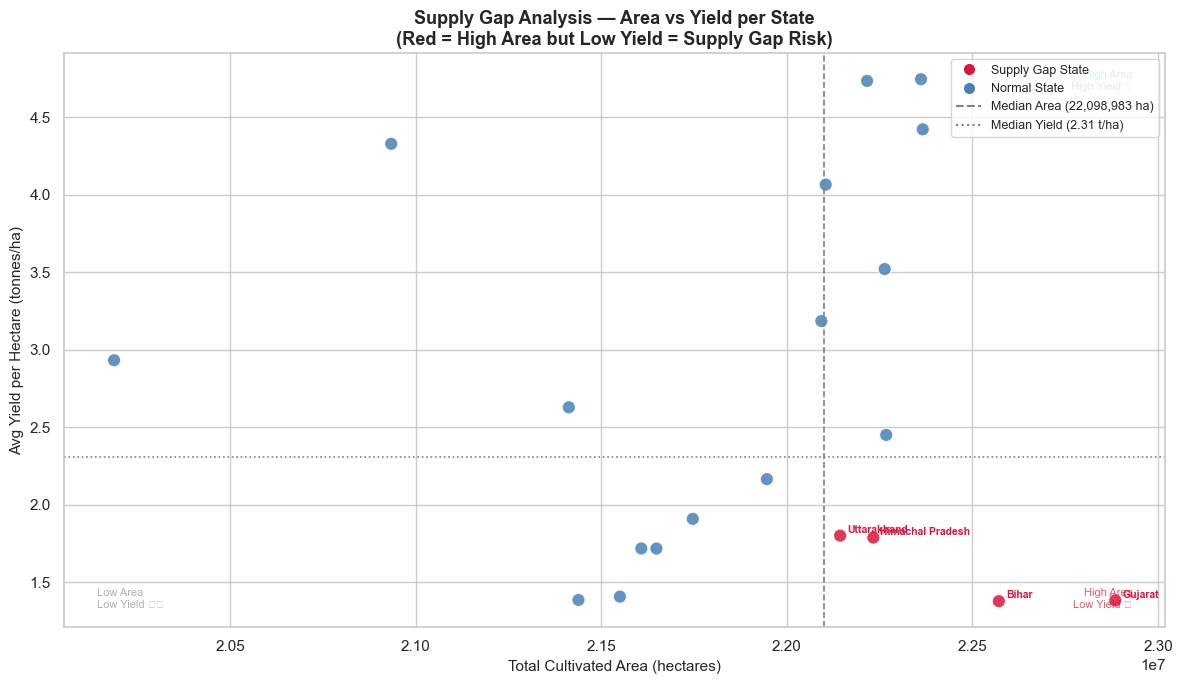

In [16]:
plt.figure(figsize=(12, 7))
colors = ['crimson' if g else 'steelblue' for g in state_summary['supply_gap']]
plt.scatter(state_summary['total_area'], state_summary['avg_yield'],
            c=colors, s=90, alpha=0.85, edgecolors='white', linewidths=0.8)

plt.axvline(med_area,  color='gray', linestyle='--', linewidth=1.2, label=f'Median Area ({med_area:,.0f} ha)')
plt.axhline(med_yield, color='gray', linestyle=':',  linewidth=1.2, label=f'Median Yield ({med_yield:.2f} t/ha)')

for _, row in gap_states.iterrows():
    plt.annotate(row['state_name'],
                 (row['total_area'], row['avg_yield']),
                 textcoords='offset points', xytext=(5, 2),
                 fontsize=7.5, ha='left', color='crimson', fontweight='bold')

# Quadrant labels
ax = plt.gca()
ax.text(0.97, 0.97, 'High Area\nHigh Yield', transform=ax.transAxes,
        fontsize=8, ha='right', va='top', color='green', alpha=0.6)
ax.text(0.03, 0.03, 'Low Area\nLow Yield', transform=ax.transAxes,
        fontsize=8, ha='left', va='bottom', color='gray', alpha=0.6)
ax.text(0.97, 0.03, 'High Area\nLow Yield', transform=ax.transAxes,
        fontsize=8, ha='right', va='bottom', color='crimson', alpha=0.7)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson',
           markersize=9, label='Supply Gap State'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=9, label='Normal State'),
    Line2D([0], [0], color='gray', linestyle='--', label=f'Median Area ({med_area:,.0f} ha)'),
    Line2D([0], [0], color='gray', linestyle=':', label=f'Median Yield ({med_yield:.2f} t/ha)'),
]
plt.legend(handles=legend_elements, fontsize=9)

plt.title('Supply Gap Analysis — Area vs Yield per State\n'
          '(Red = High Area but Low Yield = Supply Gap Risk)', fontsize=13, fontweight='bold')
plt.xlabel('Total Cultivated Area (hectares)', fontsize=11)
plt.ylabel('Avg Yield per Hectare (tonnes/ha)', fontsize=11)
plt.tight_layout()
plt.show()

worst_gap = gap_states.iloc[0]

---
## 6. Food Security Scoring — State-wise Index

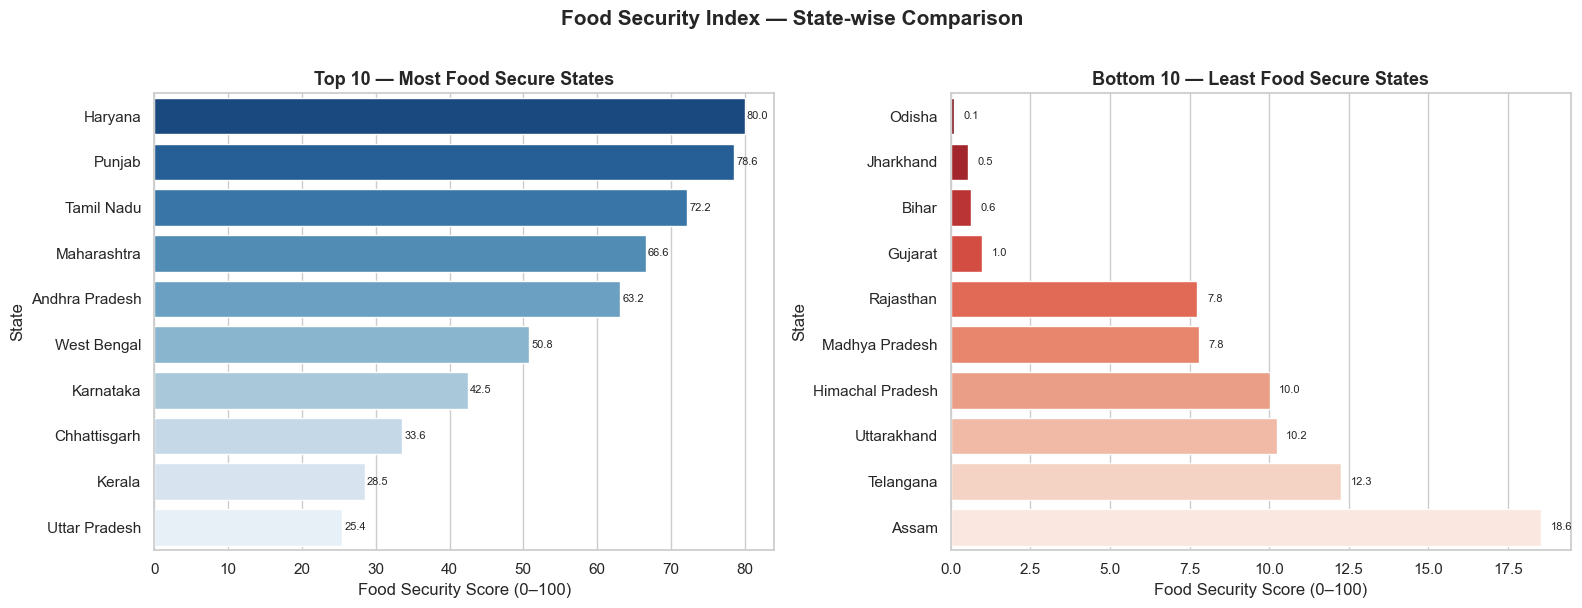

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
state_summary['prod_score'] = scaler.fit_transform(
    state_summary[['total_production']]) * 40

state_summary['yield_score'] = scaler.fit_transform(
    state_summary[['avg_yield']]) * 40
crop_diversity = (
    crop_df.groupby('state_name')['crop']
           .nunique()
           .reset_index(name='diversity')
)
state_summary = state_summary.merge(crop_diversity, on='state_name', how='left')
state_summary['diversity'] = state_summary['diversity'].fillna(0)
state_summary['div_score'] = scaler.fit_transform(
    state_summary[['diversity']]) * 20
state_summary['food_security_score'] = (
    state_summary['prod_score'] +
    state_summary['yield_score'] +
    state_summary['div_score']
).round(2)

top_secure   = state_summary.nlargest(10,  'food_security_score')
least_secure = state_summary.nsmallest(10, 'food_security_score')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_secure,   x='food_security_score', y='state_name',
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 — Most Food Secure States', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Food Security Score (0–100)')
axes[0].set_ylabel('State')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}', va='center', fontsize=8)

sns.barplot(data=least_secure, x='food_security_score', y='state_name',
            palette='Reds_r',  ax=axes[1])
axes[1].set_title('Bottom 10 — Least Food Secure States', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Food Security Score (0–100)')
axes[1].set_ylabel('State')
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}', va='center', fontsize=8)

plt.suptitle('Food Security Index — State-wise Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Crop Concentration Risk — Herfindahl Index per State

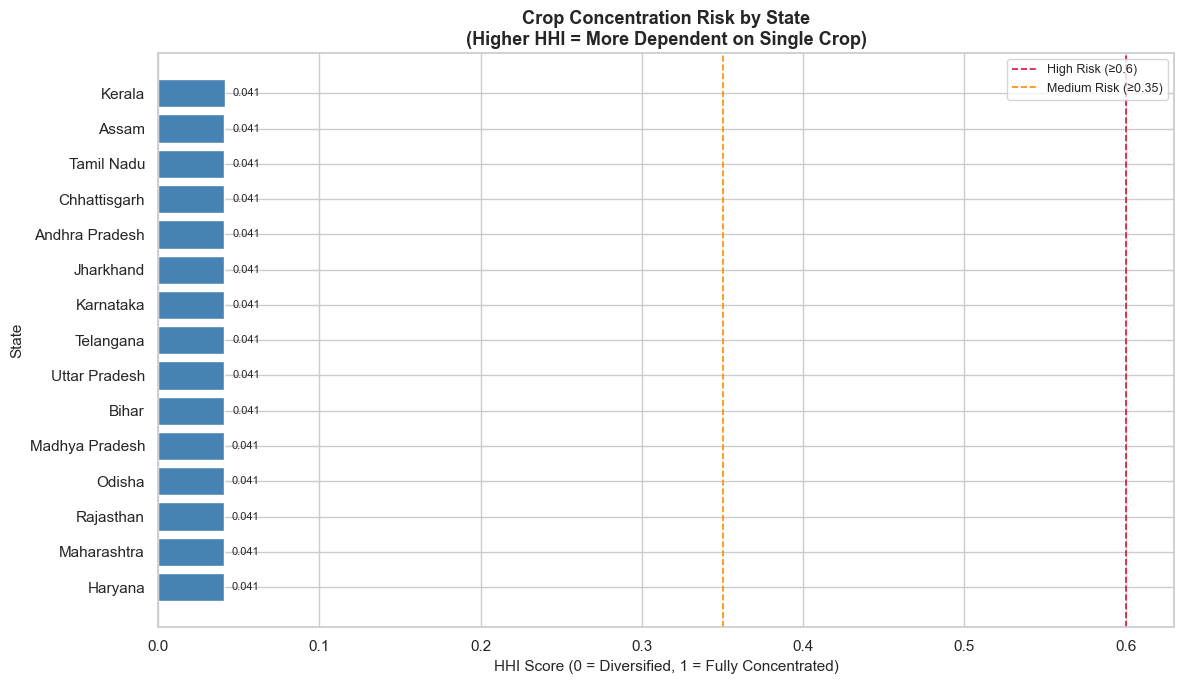

  Most concentrated state : Kerala  | HHI: 0.041
  Most diversified state  : West Bengal  | HHI: 0.040


In [18]:
# HHI: sum of (crop share)^2 per state → higher = more dependent on single crop
state_crop  = crop_df.groupby(['state_name', 'crop'])['production'].sum().reset_index()
state_total = state_crop.groupby('state_name')['production'].sum().rename('state_total')
state_crop  = state_crop.join(state_total, on='state_name')
state_crop['share'] = state_crop['production'] / state_crop['state_total']

hhi = (
    state_crop.groupby('state_name')['share']
              .apply(lambda x: (x**2).sum())
              .reset_index()
)
hhi.columns = ['state_name', 'hhi_score']
hhi = hhi.sort_values('hhi_score', ascending=False)

def hhi_color(score):
    if score >= 0.6: return 'crimson'
    elif score >= 0.35: return 'darkorange'
    else: return 'steelblue'

top_hhi = hhi.head(15).copy()
palette  = [hhi_color(s) for s in top_hhi['hhi_score']]

plt.figure(figsize=(12, 7))
bars = plt.barh(top_hhi['state_name'][::-1], top_hhi['hhi_score'][::-1], color=palette[::-1])
plt.axvline(0.6,  color='crimson',    linestyle='--', linewidth=1.2, label='High Risk (≥0.6)')
plt.axvline(0.35, color='darkorange', linestyle='--', linewidth=1.2, label='Medium Risk (≥0.35)')
plt.title('Crop Concentration Risk by State\n(Higher HHI = More Dependent on Single Crop)',
          fontsize=13, fontweight='bold')
plt.xlabel('HHI Score (0 = Diversified, 1 = Fully Concentrated)', fontsize=11)
plt.ylabel('State', fontsize=11)
plt.legend(fontsize=9)
for bar in bars:
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

most_conc = hhi.iloc[0]
most_div  = hhi.iloc[-1]
high_risk = hhi[hhi['hhi_score'] >= 0.6]

print(f'  Most concentrated state : {most_conc["state_name"]}  | HHI: {most_conc["hhi_score"]:.3f}')
print(f'  Most diversified state  : {most_div["state_name"]}  | HHI: {most_div["hhi_score"]:.3f}')

---
## 8. Seasonal Production Share — Pie Chart

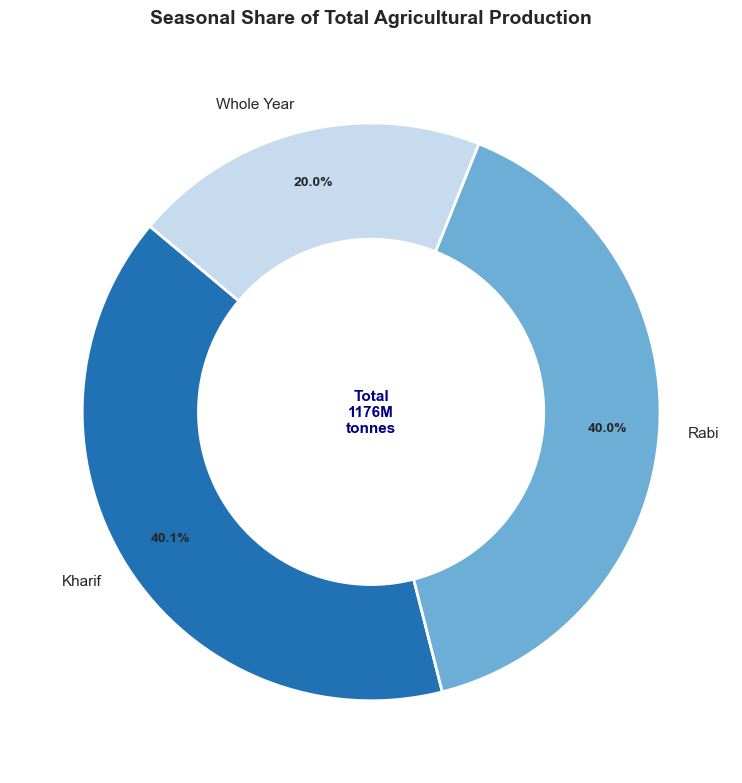

In [19]:
season_col = None
for col in ['season', 'Season', 'SEASON']:
    if col in crop_df.columns:
        season_col = col
        break

if season_col is None:
    print('No season column found. Skipping seasonal analysis.')
else:
    season_share = (
        crop_df.groupby(season_col)['production']
               .sum()
               .sort_values(ascending=False)
    )
    season_share = season_share[season_share > 0]   
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(
        season_share.values,
        labels=season_share.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('Blues_r', len(season_share)),
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        pctdistance=0.82
    )
    centre_circle = plt.Circle((0, 0), 0.60, fc='white')
    ax.add_patch(centre_circle)
    ax.text(0, 0, f'Total\n{season_share.sum()/1e6:.0f}M\ntonnes',
            ha='center', va='center', fontsize=11, fontweight='bold', color='navy')

    for at in autotexts:
        at.set_fontsize(10)
        at.set_fontweight('bold')

    plt.title('Seasonal Share of Total Agricultural Production',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    dominant = season_share.index[0]
    dominant_pct = season_share.values[0] / season_share.sum() * 100

---
## 9. Price Volatility vs Average Price — Commodity Risk Map

In [1]:
price_num_cols = price_df.select_dtypes(include='number').columns.tolist()
price_col_candidates = [c for c in price_num_cols
                        if any(kw in c for kw in ['price', 'modal', 'min', 'max', 'value'])]

commodity_col_candidates = [c for c in price_df.columns
                             if any(kw in c for kw in ['commodity', 'crop', 'item', 'product'])]

if commodity_col_candidates and price_col_candidates:
    comm_col  = commodity_col_candidates[0]
    price_val = price_col_candidates[0]
    print(f'Detected long format — commodity: "{comm_col}", price: "{price_val}"')
    volatility_df = (
        price_df.groupby(comm_col)[price_val]
                .agg(avg_price='mean', price_std='std')
                .reset_index()
                .rename(columns={comm_col: 'commodity'})
    )
    volatility_df['cv_pct'] = (
        volatility_df['price_std'] / volatility_df['avg_price'] * 100
    )
    volatility_df = volatility_df.dropna().query('avg_price > 0')
else:
    print(f'Detected wide format — using {len(price_num_cols)} numeric columns as commodities')
    price_num_cols = [c for c in price_num_cols if price_df[c].std() > 0]
    volatility_df = pd.DataFrame({
        'commodity' : price_num_cols,
        'avg_price' : price_df[price_num_cols].mean().values,
        'price_std' : price_df[price_num_cols].std().values,
        'cv_pct'    : (price_df[price_num_cols].std() /
                       price_df[price_num_cols].mean() * 100).values
    }).dropna()

if volatility_df.empty:
    print('Not enough price data for volatility plot.')
else:
    size_vals = (volatility_df['price_std'] /
                 volatility_df['price_std'].max() * 400 + 30)

    plt.figure(figsize=(11, 6))
    scatter = plt.scatter(
        volatility_df['avg_price'],
        volatility_df['cv_pct'],
        s=size_vals,
        c=volatility_df['cv_pct'],
        cmap='RdYlGn_r', alpha=0.85, edgecolors='white', linewidths=0.8
    )

    for _, row in volatility_df.iterrows():
        plt.annotate(str(row['commodity']),
                     (row['avg_price'], row['cv_pct']),
                     textcoords='offset points', xytext=(5, 3),
                     fontsize=8, ha='left', va='bottom')

    plt.colorbar(scatter, label='CV % (Volatility Level)')
    plt.title('Price Volatility vs Average Price — Commodity Risk Map',
              fontsize=13, fontweight='bold')
    plt.xlabel('Average Price (₹)', fontsize=11)
    plt.ylabel('Coefficient of Variation % (Price Volatility)', fontsize=11)
    plt.tight_layout()
    plt.show()

    most_volatile = volatility_df.loc[volatility_df['cv_pct'].idxmax()]
    most_stable   = volatility_df.loc[volatility_df['cv_pct'].idxmin()]

NameError: name 'price_df' is not defined

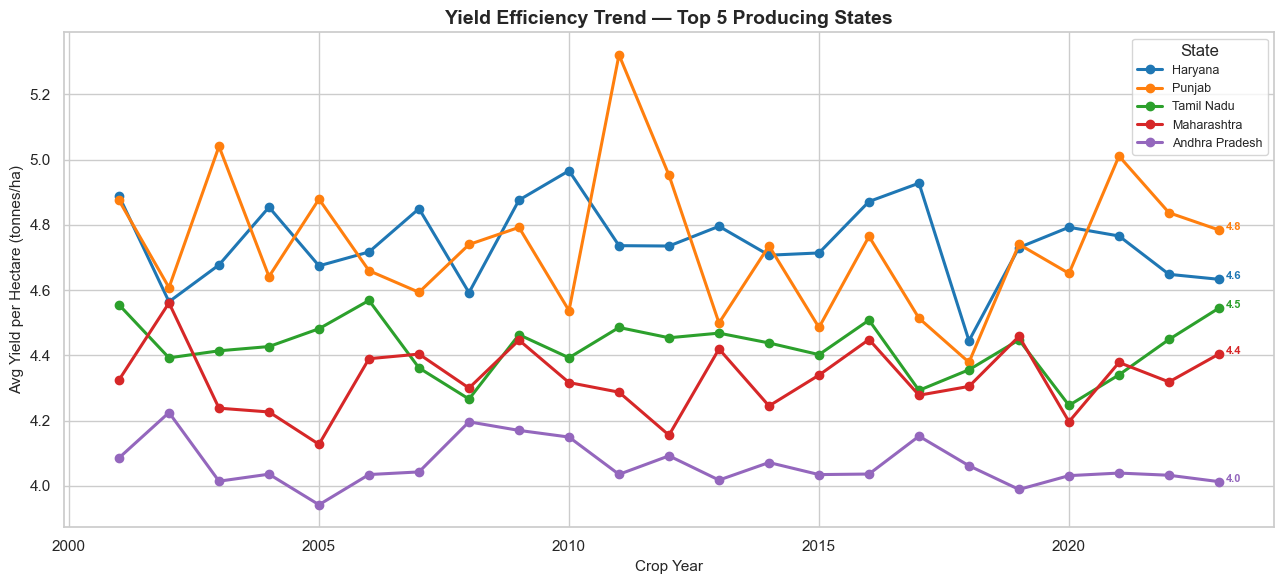


📊 Yield CAGR by State (first year → last year):
  Haryana                        CAGR: -0.24% per year
  Punjab                         CAGR: -0.09% per year
  Tamil Nadu                     CAGR: -0.01% per year
  Maharashtra                    CAGR: +0.08% per year
  Andhra Pradesh                 CAGR: -0.08% per year


In [21]:
top5_states  = crop_df.groupby('state_name')['production'].sum().nlargest(5).index
df_top5      = crop_df[crop_df['state_name'].isin(top5_states)]
yield_trend  = (
    df_top5.groupby(['crop_year', 'state_name'])['yield_per_hectare']
           .mean()
           .reset_index()
)

palette_states = sns.color_palette('tab10', len(top5_states))

plt.figure(figsize=(13, 6))
for i, state in enumerate(top5_states):
    data = yield_trend[yield_trend['state_name'] == state].sort_values('crop_year')
    plt.plot(data['crop_year'], data['yield_per_hectare'],
             marker='o', linewidth=2.2, label=state, color=palette_states[i])
    if not data.empty:
        last = data.iloc[-1]
        plt.annotate(f"{last['yield_per_hectare']:.1f}",
                     (last['crop_year'], last['yield_per_hectare']),
                     textcoords='offset points', xytext=(5, 0),
                     fontsize=8, color=palette_states[i], fontweight='bold')

plt.title('Yield Efficiency Trend — Top 5 Producing States', fontsize=14, fontweight='bold')
plt.xlabel('Crop Year', fontsize=11)
plt.ylabel('Avg Yield per Hectare (tonnes/ha)', fontsize=11)
plt.legend(title='State', fontsize=9)
plt.tight_layout()
plt.show()

print('\n Yield CAGR by State (first year → last year):')
for state in top5_states:
    d = yield_trend[yield_trend['state_name'] == state].sort_values('crop_year')
    if len(d) >= 2:
        y0, yn = d.iloc[0]['yield_per_hectare'], d.iloc[-1]['yield_per_hectare']
        n = d.iloc[-1]['crop_year'] - d.iloc[0]['crop_year']
        cagr = ((yn / y0) ** (1 / n) - 1) * 100 if n > 0 and y0 > 0 else 0
        print(f'  {state:<30} CAGR: {cagr:+.2f}% per year')

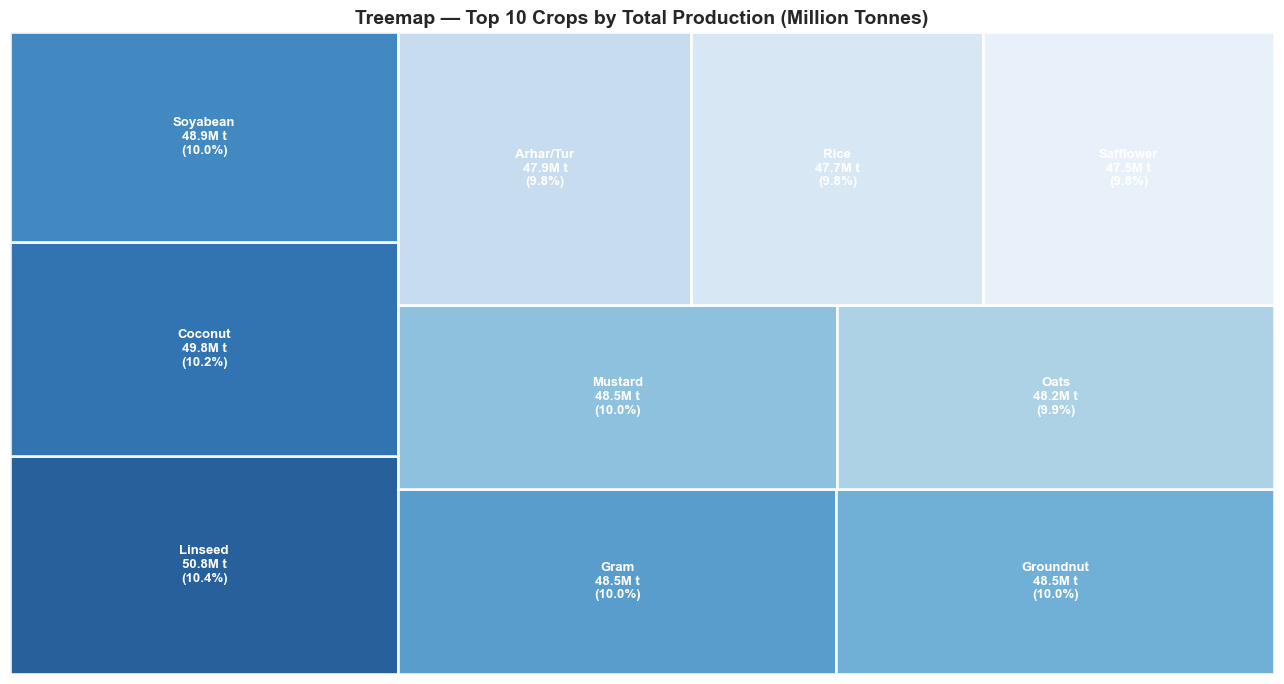

In [22]:
try:
    import squarify
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'squarify', '-q'])
    import squarify

top10_crop_prod = crop_df.groupby('crop')['production'].sum().nlargest(10)

plt.figure(figsize=(13, 7))
squarify.plot(
    sizes=top10_crop_prod.values,
    label=[
        f"{c}\n{v/1e6:.1f}M t\n({v/top10_crop_prod.sum()*100:.1f}%)"
        for c, v in zip(top10_crop_prod.index, top10_crop_prod.values)
    ],
    color=sns.color_palette('Blues_r', 10),
    alpha=0.87,
    edgecolor='white',
    linewidth=2,
    text_kwargs={'fontsize': 9.5, 'fontweight': 'bold', 'color': 'white'}
)
plt.title('Treemap — Top 10 Crops by Total Production (Million Tonnes)',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

top1 = top10_crop_prod.index[0]
top1_share = top10_crop_prod.values[0] / top10_crop_prod.sum() * 100

In [25]:
final_summary = (
    state_summary[[
        'state_name', 'total_area', 'total_production',
        'avg_yield', 'food_security_score', 'supply_gap', 'diversity'
    ]]
    .merge(hhi, on='state_name', how='left')
    .sort_values('food_security_score', ascending=False)
    .reset_index(drop=True)
)

final_summary.to_csv('smart_agriculture_summary.csv', index=False)
print('smart_agriculture_summary.csv saved — ready for Power BI dashboard!')
print()
print('Top 10 States by Food Security Score:')
print(final_summary.head(10).to_string(index=False))

smart_agriculture_summary.csv saved — ready for Power BI dashboard!

Top 10 States by Food Security Score:
    state_name  total_area  total_production  avg_yield  food_security_score  supply_gap  diversity  hhi_score
       Haryana 22361536.50      106991567.96       4.75                80.00       False         25       0.04
        Punjab 22216279.18      104568204.40       4.73                78.62       False         25       0.04
    Tamil Nadu 22366324.34       99337276.31       4.42                72.19       False         25       0.04
   Maharashtra 20934011.19       90649051.19       4.33                66.57       False         25       0.04
Andhra Pradesh 22104838.68       90108330.03       4.07                63.17       False         25       0.04
   West Bengal 22263681.46       78739725.58       3.52                50.80       False         25       0.04
     Karnataka 22093127.21       70340090.26       3.18                42.46       False         25       0.04
  Chh

---


